In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter
sns.set_style('whitegrid')
sns.set_palette("Set2")

%matplotlib inline

# Leer los datos

In [3]:
df_fe = pd.read_csv("../../data/respuestas_fede.csv")
print(df_fe.shape)

#globales
marmol = df_fe.loc[df_fe["escuela"] == "Colegio Modelo Mármol"]
mantovani = df_fe.loc[df_fe["escuela"] == "Escuela Nueva Juan Mantovani"]
cant_total = len(df_fe)
cant_marmol = len(marmol)
cant_mantovani = len(mantovani)
# genero
cant_marmol_masc = len(marmol[marmol['genero']=="Masculino"])
cant_marmol_fem = len(marmol[marmol['genero']=="Femenino"])
cant_mantovani_masc = len(mantovani[mantovani['genero']=="Masculino"])
cant_mantovani_fem = len(mantovani[mantovani['genero']=="Femenino"])
# grados
cant_marmol_quinto = len(marmol[marmol['grado']=="Quinto"])
cant_marmol_sexto = len(marmol[marmol['grado']=="Sexto"])
cant_mantovani_cuarto = len(mantovani[mantovani['grado']=="Cuarto"])
cant_mantovani_quinto = len(mantovani[mantovani['grado']=="Quinto"])
cant_mantovani_sexto = len(mantovani[mantovani['grado']=="Sexto"])

(369, 22)


## ¿Dónde se almacenan los videos que están en YouTube? 

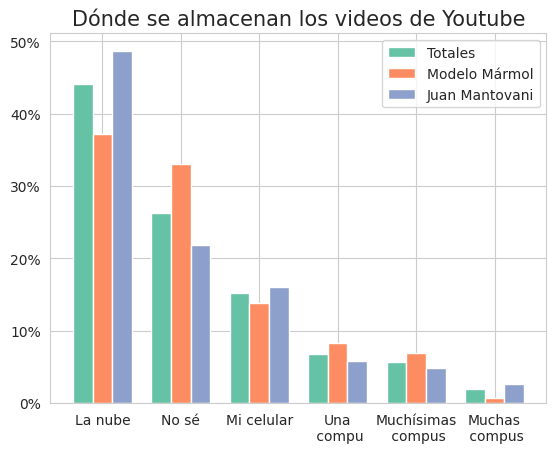

In [21]:
# ¿Dónde se almacenan los videos que están en YouTube? 
data_total = df_fe["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol = marmol["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani = mantovani["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"},
                       index={"En la nube": "La nube",
                              "En mi celular": "Mi celular",
                              "En una computadora": "Una\n compu",
                              "En muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas\n compus",
                              "En muchas computadoras (tantas que podrían llenar una casa)": "Muchas\n compus"}).fillna(0)

bar_width = 0.25

br1 = np.arange(len(data_total))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales'],        width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Mármol'],  width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Dónde se almacenan los videos de Youtube", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()
plt.savefig('donde_youtube.png')

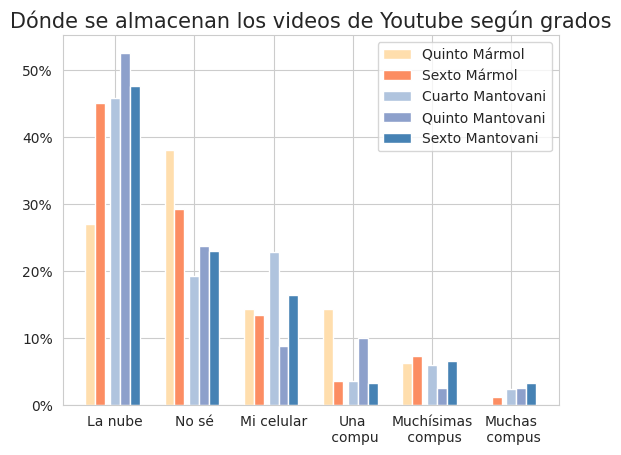

In [28]:
# ¿Dónde se almacenan los videos que están en YouTube? - Grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0:'Quinto Mármol',
                                1:'Sexto Mármol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'},
                        index={"En la nube": "La nube",
                              "En mi celular": "Mi celular",
                              "En una computadora": "Una\n compu",
                              "En muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas\n compus",
                              "En muchas computadoras (tantas que podrían llenar una casa)": "Muchas\n compus"}).fillna(0)

result = result.reindex(["La nube", 
                         "No sé",
                         "Mi celular", 
                         "Una\n compu",
                         "Muchísimas\n compus",
                         "Muchas\n compus"])

bar_width = 0.25

br1 = [1, 3, 5, 7, 9, 11]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Mármol']    , width=bar_width, label = 'Quinto Mármol', color='navajowhite')
plt.bar(br2, result['Sexto Mármol']     , width=bar_width, label = 'Sexto Mármol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'] , width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'] , width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani']  , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Dónde se almacenan los videos de Youtube según grados", fontsize=15)
plt.xticks([x + 2.5*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('donde_youtube_grados.png')


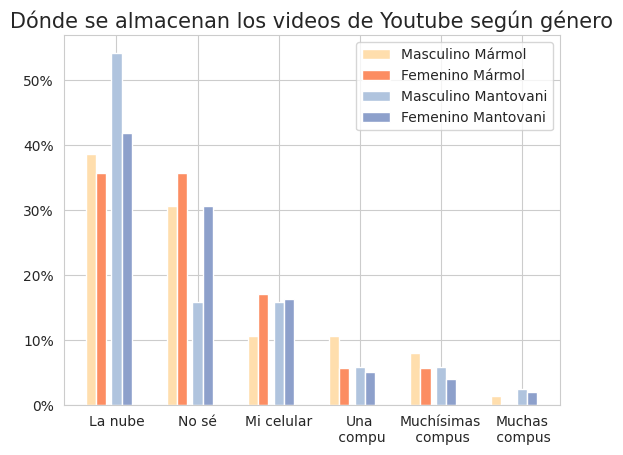

In [29]:
# ¿Dónde se almacenan los videos que están en YouTube? - Género
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Mármol", 1: "Femenino Mármol", 2: "Masculino Mantovani", 3: "Femenino Mantovani"},
                       index={"En la nube": "La nube",
                              "En mi celular": "Mi celular",
                              "En una computadora": "Una\n compu",
                              "En muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas\n compus",
                              "En muchas computadoras (tantas que podrían llenar una casa)": "Muchas\n compus"}).fillna(0)

result = result.reindex(["La nube", 
                         "No sé",
                         "Mi celular", 
                         "Una\n compu",
                         "Muchísimas\n compus",
                         "Muchas\n compus"])

bar_width = 0.25

br1 = [1, 3, 5, 7, 9, 11]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Mármol"],     width=bar_width, label = 'Masculino Mármol', color='navajowhite')
plt.bar(br2,result["Femenino Mármol"],      width=bar_width, label = 'Femenino Mármol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Dónde se almacenan los videos de Youtube según género", fontsize=15)
plt.xticks([x + 2.5*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('donde_youtube_genero.png')


# ¿Quién tiene acceso a las fotos que tengo guardadas en mi celular?

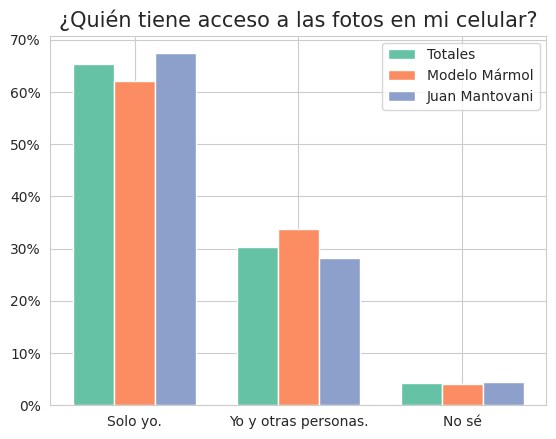

In [31]:
# Quien tiene acceso a las fotos en mi celular
data_total = df_fe["quien_acceso_celular"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol = marmol["quien_acceso_celular"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani = mantovani["quien_acceso_celular"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"})

bar_width = 0.25

br1 = np.arange(len(data_total))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales'],        width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Mármol'],  width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("¿Quién tiene acceso a las fotos en mi celular?", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()
plt.savefig('quien_acceso_celular.png')

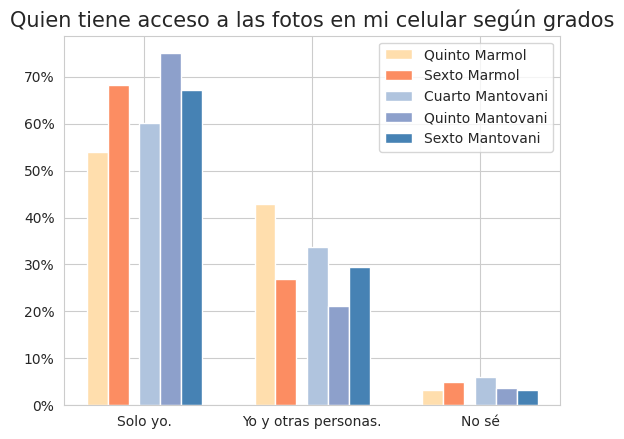

In [32]:
# Quien tiene acceso a las fotos en mi celular - Grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["quien_acceso_celular"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["quien_acceso_celular"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["quien_acceso_celular"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["quien_acceso_celular"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["quien_acceso_celular"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0:'Quinto Marmol',
                                1:'Sexto Marmol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'})

bar_width = 0.25

br1 = [1, 3, 5]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Marmol']    , width=bar_width, label = 'Quinto Marmol', color='navajowhite')
plt.bar(br2, result['Sexto Marmol']     , width=bar_width, label = 'Sexto Marmol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'] , width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'] , width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani']  , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Quien tiene acceso a las fotos en mi celular según grados", fontsize=15)
plt.xticks([x + 2.25*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('quien_acceso_celular_grados.png')


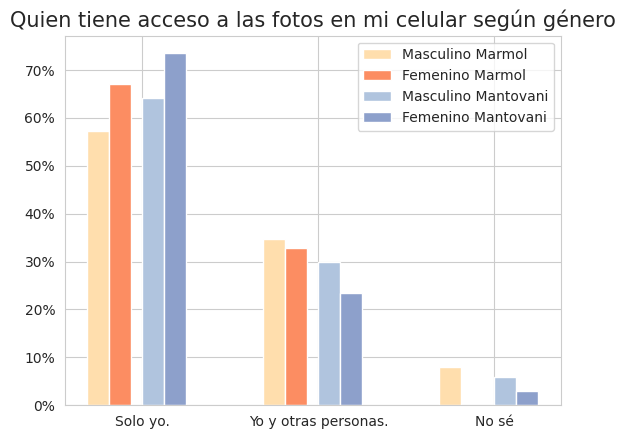

In [33]:
# Quien tiene acceso a las fotos en mi celular - Género
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["quien_acceso_celular"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["quien_acceso_celular"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["quien_acceso_celular"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["quien_acceso_celular"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Marmol", 1: "Femenino Marmol", 2: "Masculino Mantovani", 3: "Femenino Mantovani"})

bar_width = 0.25

br1 = [1, 3, 5]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Marmol"],     width=bar_width, label = 'Masculino Marmol', color='navajowhite')
plt.bar(br2,result["Femenino Marmol"],      width=bar_width, label = 'Femenino Marmol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Quien tiene acceso a las fotos en mi celular según género", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('quien_acceso_celular_genero.png')


# Cuando le mando a una amiga una foto por WhatsApp..

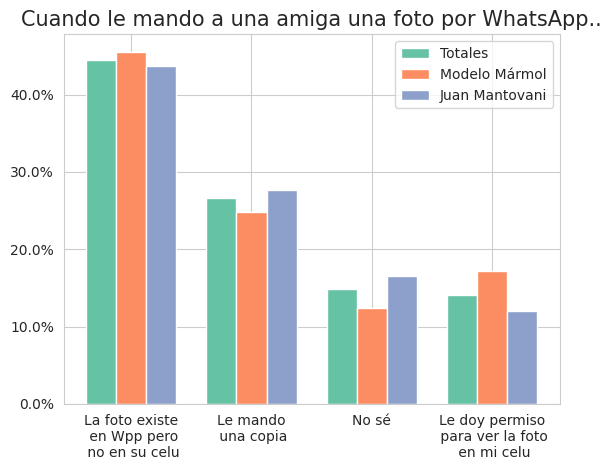

In [37]:
# Cuando le mando a una amiga una foto por WhatsApp..
data_total = df_fe["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol = marmol["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani = mantovani["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"},
                       index={"La foto ahora existe en WhatsApp y mi amiga la puede ver cuando mira nuestro chat, pero no la tiene en su celular":"La foto existe\n en Wpp pero\n no en su celu",
                              "Le mando una copia de mi foto.": "Le mando\n una copia",
                              "Le doy permiso para ver la foto que tengo guardada en mi celular.": "Le doy permiso\n para ver la foto\n en mi celu"}).fillna(0)

bar_width = 0.25

br1 = np.arange(len(data_total))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales'],        width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Mármol'],  width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Cuando le mando a una amiga una foto por WhatsApp..", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()
plt.savefig('amiga_wpp.png')

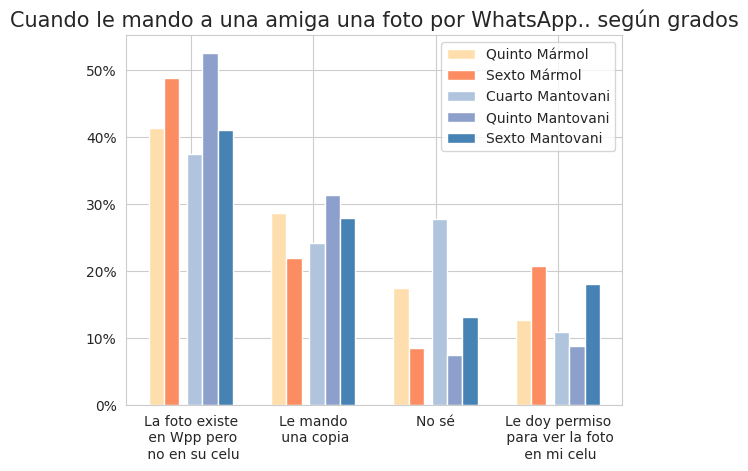

In [40]:
# Cuando le mando a una amiga una foto por WhatsApp.. - Grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0:'Quinto Mármol',
                                1:'Sexto Mármol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'},
                       index={"La foto ahora existe en WhatsApp y mi amiga la puede ver cuando mira nuestro chat, pero no la tiene en su celular":"La foto existe\n en Wpp pero\n no en su celu",
                              "Le mando una copia de mi foto.": "Le mando\n una copia",
                              "Le doy permiso para ver la foto que tengo guardada en mi celular.": "Le doy permiso\n para ver la foto\n en mi celu"}).fillna(0)

result = result.reindex(["La foto existe\n en Wpp pero\n no en su celu",
                         "Le mando\n una copia",
                         "No sé",
                         "Le doy permiso\n para ver la foto\n en mi celu"])

bar_width = 0.25

br1 = [1, 3, 5, 7]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Mármol']    , width=bar_width, label = 'Quinto Mármol', color='navajowhite')
plt.bar(br2, result['Sexto Mármol']     , width=bar_width, label = 'Sexto Mármol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'] , width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'] , width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani']  , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Cuando le mando a una amiga una foto por WhatsApp.. según grados", fontsize=15)
plt.xticks([x + 2.25*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('amiga_wpp_grados.png')

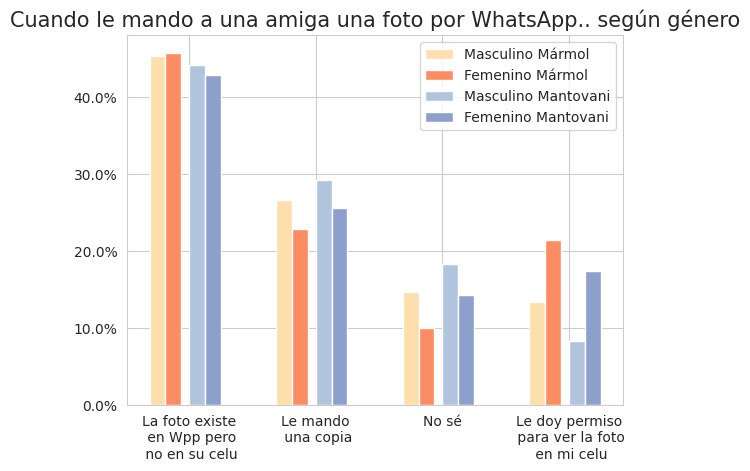

In [42]:
# Cuando le mando a una amiga una foto por WhatsApp.. - Género
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Mármol", 1: "Femenino Mármol", 2: "Masculino Mantovani", 3: "Femenino Mantovani"},
                       index={"La foto ahora existe en WhatsApp y mi amiga la puede ver cuando mira nuestro chat, pero no la tiene en su celular":"La foto existe\n en Wpp pero\n no en su celu",
                              "Le mando una copia de mi foto.": "Le mando\n una copia",
                              "Le doy permiso para ver la foto que tengo guardada en mi celular.": "Le doy permiso\n para ver la foto\n en mi celu"}).fillna(0)

result = result.reindex(["La foto existe\n en Wpp pero\n no en su celu",
                         "Le mando\n una copia",
                         "No sé",
                         "Le doy permiso\n para ver la foto\n en mi celu"])

bar_width = 0.25

br1 = [1, 3, 5, 7]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Mármol"],     width=bar_width, label = 'Masculino Mármol', color='navajowhite')
plt.bar(br2,result["Femenino Mármol"],      width=bar_width, label = 'Femenino Mármol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Cuando le mando a una amiga una foto por WhatsApp.. según género", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('amiga_wpp_genero.png')

# Si quiero hacer que mi amiga no pueda ver más la foto, ¿qué puedo hacer?

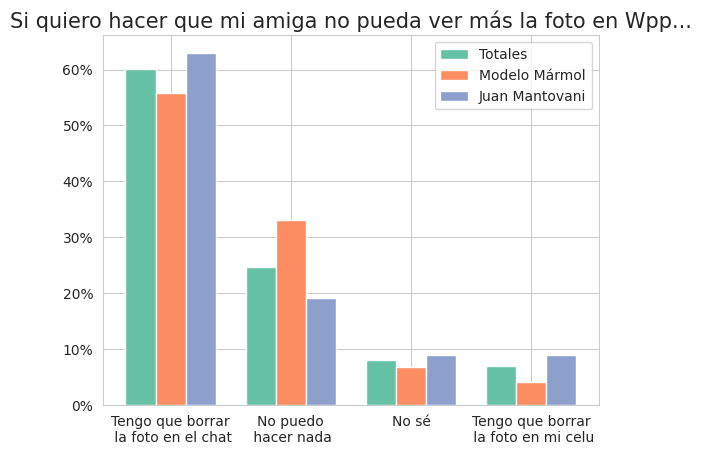

In [8]:
# Si quiero hacer que mi amiga no pueda ver más la foto, ¿qué puedo hacer?
data_total = df_fe["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol = marmol["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani = mantovani["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"},
                       index={"Tengo que borrar la foto en el chat.": "Tengo que borrar\n la foto en el chat",
                              "No puedo hacer nada, mi amiga ahora también tiene la foto y no tengo manera de sacársela.": "No puedo\n hacer nada",
                              "Tengo que borrar la foto en la Galería de fotos de mi celular.": "Tengo que borrar\n la foto en mi celu"}).fillna(0)

result = result.reindex(["Tengo que borrar\n la foto en el chat",
          "No puedo\n hacer nada", 
          "No sé", 
          "Tengo que borrar\n la foto en mi celu"])

bar_width = 0.25

br1 = np.arange(len(data_total))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales'],        width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Mármol'],  width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Si quiero hacer que mi amiga no pueda ver más la foto en Wpp...", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()
plt.savefig('amiga_no_ver_foto.png')

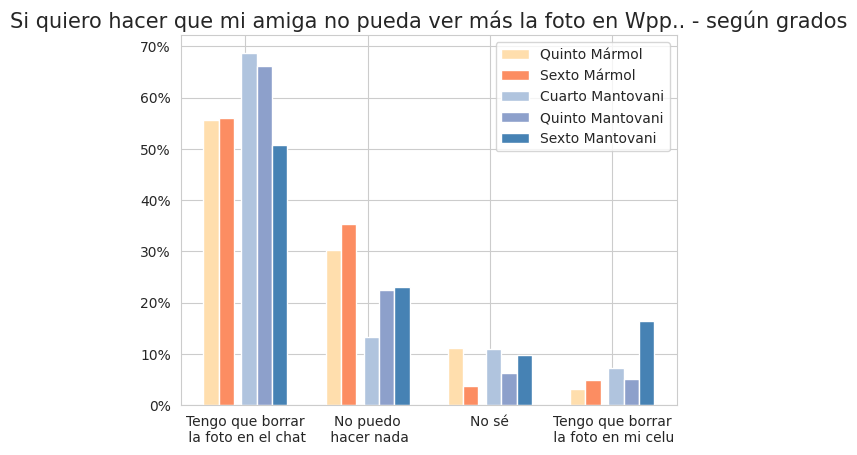

In [12]:
# Si quiero hacer que mi amiga no pueda ver más la foto, ¿qué puedo hacer? - Grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0:'Quinto Mármol',
                                1:'Sexto Mármol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'},
                       index={"Tengo que borrar la foto en el chat.": "Tengo que borrar\n la foto en el chat",
                              "No puedo hacer nada, mi amiga ahora también tiene la foto y no tengo manera de sacársela.": "No puedo\n hacer nada",
                              "Tengo que borrar la foto en la Galería de fotos de mi celular.": "Tengo que borrar\n la foto en mi celu"}).fillna(0)

result = result.reindex(["Tengo que borrar\n la foto en el chat",
          "No puedo\n hacer nada", 
          "No sé", 
          "Tengo que borrar\n la foto en mi celu"])

bar_width = 0.25

br1 = [1, 3, 5, 7]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Mármol']    , width=bar_width, label = 'Quinto Mármol', color='navajowhite')
plt.bar(br2, result['Sexto Mármol']     , width=bar_width, label = 'Sexto Mármol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'] , width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'] , width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani']  , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Si quiero hacer que mi amiga no pueda ver más la foto en Wpp.. - según grados", fontsize=15)
plt.xticks([x + 2.25*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('amiga_no_ver_foto_grados.png')

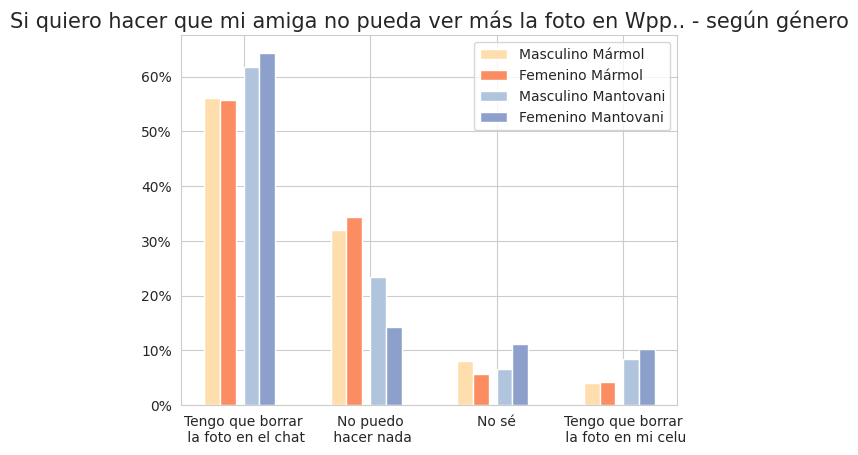

In [13]:
# Si quiero hacer que mi amiga no pueda ver más la foto, ¿qué puedo hacer? - Género
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Mármol", 1: "Femenino Mármol", 2: "Masculino Mantovani", 3: "Femenino Mantovani"},
                       index={"Tengo que borrar la foto en el chat.": "Tengo que borrar\n la foto en el chat",
                              "No puedo hacer nada, mi amiga ahora también tiene la foto y no tengo manera de sacársela.": "No puedo\n hacer nada",
                              "Tengo que borrar la foto en la Galería de fotos de mi celular.": "Tengo que borrar\n la foto en mi celu"}).fillna(0)

result = result.reindex(["Tengo que borrar\n la foto en el chat",
          "No puedo\n hacer nada", 
          "No sé", 
          "Tengo que borrar\n la foto en mi celu"])

bar_width = 0.25

br1 = [1, 3, 5, 7]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Mármol"],     width=bar_width, label = 'Masculino Mármol', color='navajowhite')
plt.bar(br2,result["Femenino Mármol"],      width=bar_width, label = 'Femenino Mármol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Si quiero hacer que mi amiga no pueda ver más la foto en Wpp.. - según género", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('amiga_no_ver_foto_genero.png')

# ¿Cómo viaja un mensaje de Wpp sin Wi-Fi?

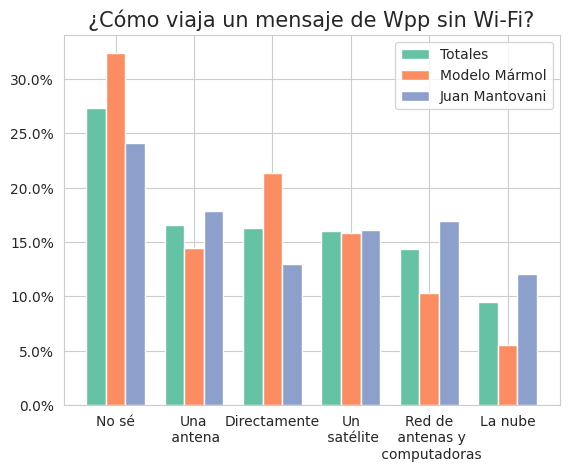

In [18]:
# ¿Cómo viaja un mensaje de Wpp sin Wi-Fi?
data_total = df_fe["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol = marmol["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani = mantovani["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"},
                       index={"El mensaje se manda a través de una antena.": "Una\n antena",
                              "El mensaje se manda directamente.": "Directamente",
                              "El mensaje se manda a través de un satélite.": "Un\n satélite",
                              "El mensaje se manda a través de una red de antenas y computadoras.": "Red de\n antenas y\n computadoras",
                              "El mensaje se manda a través de la nube.": "La nube"}).fillna(0)

result = result.reindex(["No sé", "Una\n antena", "Directamente", "Un\n satélite", "Red de\n antenas y\n computadoras", "La nube"])

bar_width = 0.25

br1 = np.arange(len(data_total))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales'],        width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Mármol'],  width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("¿Cómo viaja un mensaje de Wpp sin Wi-Fi?", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()
plt.savefig('como_viaja_wpp.png')

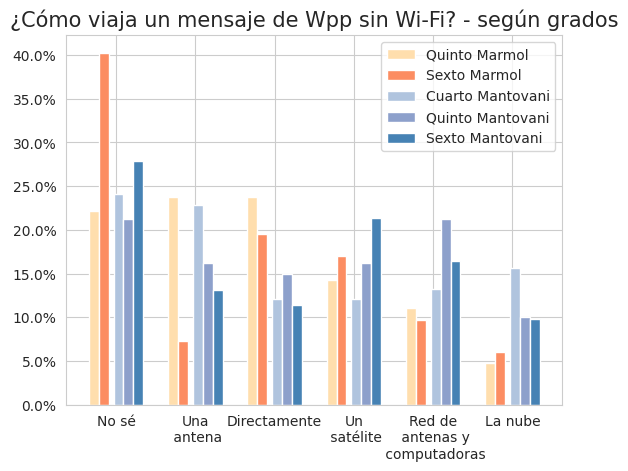

In [19]:
# ¿Cómo viaja un mensaje de Wpp sin Wi-Fi? - Grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0:'Quinto Marmol',
                                1:'Sexto Marmol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'},
                       index={"El mensaje se manda a través de una antena.": "Una\n antena",
                              "El mensaje se manda directamente.": "Directamente",
                              "El mensaje se manda a través de un satélite.": "Un\n satélite",
                              "El mensaje se manda a través de una red de antenas y computadoras.": "Red de\n antenas y\n computadoras",
                              "El mensaje se manda a través de la nube.": "La nube"}).fillna(0)

result = result.reindex(["No sé", "Una\n antena", "Directamente", "Un\n satélite", "Red de\n antenas y\n computadoras", "La nube"])

br1 = [1, 3, 5, 7, 9, 11]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Marmol']    , width=bar_width, label = 'Quinto Marmol', color='navajowhite')
plt.bar(br2, result['Sexto Marmol']     , width=bar_width, label = 'Sexto Marmol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'] , width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'] , width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani']  , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("¿Cómo viaja un mensaje de Wpp sin Wi-Fi? - según grados", fontsize=15)
plt.xticks([x + 2.25*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('como_viaja_wpp_grados.png')

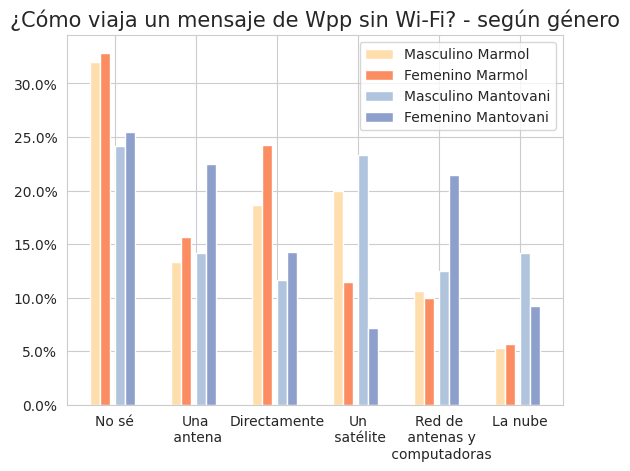

In [20]:
# ¿Cómo viaja un mensaje de Wpp sin Wi-Fi? - Género
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Marmol", 1: "Femenino Marmol", 2: "Masculino Mantovani", 3: "Femenino Mantovani"},
                       index={"El mensaje se manda a través de una antena.": "Una\n antena",
                              "El mensaje se manda directamente.": "Directamente",
                              "El mensaje se manda a través de un satélite.": "Un\n satélite",
                              "El mensaje se manda a través de una red de antenas y computadoras.": "Red de\n antenas y\n computadoras",
                              "El mensaje se manda a través de la nube.": "La nube"}).fillna(0)

result = result.reindex(["No sé", "Una\n antena", "Directamente", "Un\n satélite", "Red de\n antenas y\n computadoras", "La nube"])

bar_width = 0.25

br1 = [1, 3, 5, 7, 9 , 11]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Marmol"],     width=bar_width, label = 'Masculino Marmol', color='navajowhite')
plt.bar(br2,result["Femenino Marmol"],      width=bar_width, label = 'Femenino Marmol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("¿Cómo viaja un mensaje de Wpp sin Wi-Fi? - según género", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('como_viaja_wpp_genero.png')

# Si me llega un mensaje por WhatsApp con un link para descargar una aplicación, ¿cuál de las siguientes opciones creés que es la correcta?

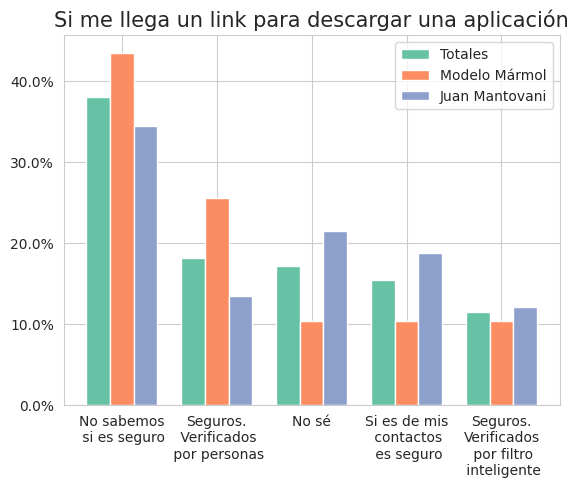

In [25]:
# Si me llega un mensaje por WhatsApp con un link para descargar una aplicación
data_total = df_fe["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol = marmol["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani = mantovani["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"},
                       index={"Los mensajes recibidos no están verificados de ninguna forma. No podemos saber si el link es seguro.": "No sabemos\n si es seguro",
                              "Los mensajes recibidos están verificados por personas en WhatsApp. El link es seguro.": "Seguros.\n Verificados\n por personas",
                              "No sé.": "No sé",
                              "Si el mensaje fue enviado por uno de mis contactos entonces el link es seguro.": "Si es de mis\n contactos\n es seguro",
                              "Los mensajes recibidos están verificados por un filtro inteligente. El link es seguro.": "Seguros.\nVerificados\n por filtro\n inteligente"}).fillna(0)

result = result.reindex(["No sabemos\n si es seguro", "Seguros.\n Verificados\n por personas", "No sé", "Si es de mis\n contactos\n es seguro", "Seguros.\nVerificados\n por filtro\n inteligente"])

bar_width = 0.25

br1 = np.arange(len(data_total))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales'],        width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Mármol'],  width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Si me llega un link para descargar una aplicación", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()
plt.savefig('link_descarga.png')

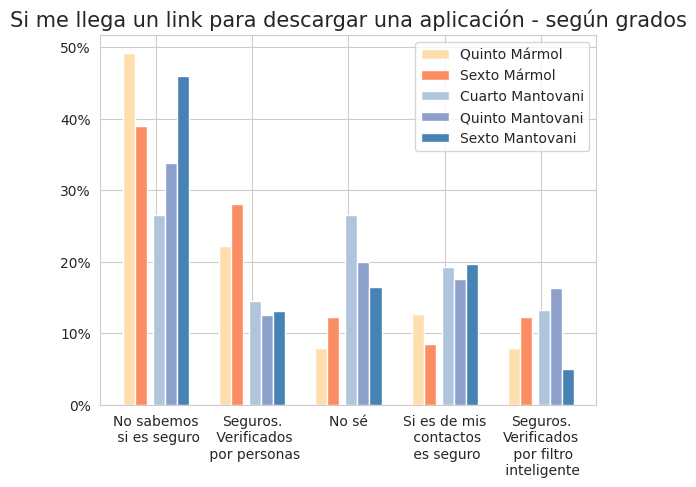

In [26]:
# Si me llega un link para descargar una aplicación - Grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0:'Quinto Mármol',
                                1:'Sexto Mármol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'},
                       index={"Los mensajes recibidos no están verificados de ninguna forma. No podemos saber si el link es seguro.": "No sabemos\n si es seguro",
                              "Los mensajes recibidos están verificados por personas en WhatsApp. El link es seguro.": "Seguros.\n Verificados\n por personas",
                              "No sé.": "No sé",
                              "Si el mensaje fue enviado por uno de mis contactos entonces el link es seguro.": "Si es de mis\n contactos\n es seguro",
                              "Los mensajes recibidos están verificados por un filtro inteligente. El link es seguro.": "Seguros.\nVerificados\n por filtro\n inteligente"}).fillna(0)

result = result.reindex(["No sabemos\n si es seguro", "Seguros.\n Verificados\n por personas", "No sé", "Si es de mis\n contactos\n es seguro", "Seguros.\nVerificados\n por filtro\n inteligente"])

br1 = [1, 3, 5, 7, 9]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Mármol']    , width=bar_width, label = 'Quinto Mármol', color='navajowhite')
plt.bar(br2, result['Sexto Mármol']     , width=bar_width, label = 'Sexto Mármol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'] , width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'] , width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani']  , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Si me llega un link para descargar una aplicación - según grados", fontsize=15)
plt.xticks([x + 2.25*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('link_descarga_grados.png')

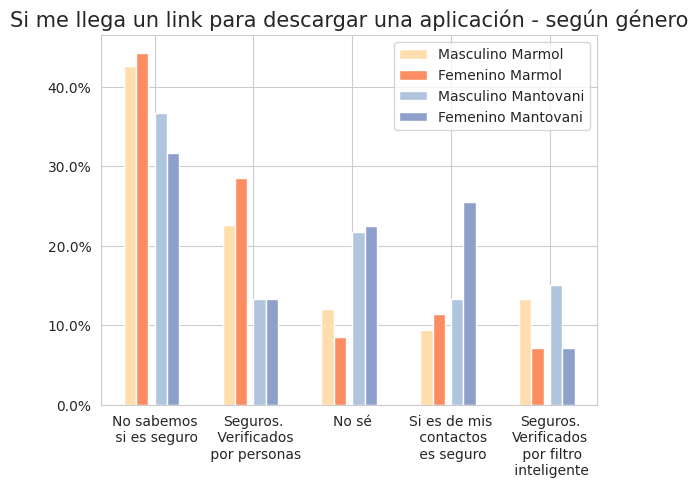

In [27]:
# Si me llega un link para descargar una aplicación - Género
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Marmol", 1: "Femenino Marmol", 2: "Masculino Mantovani", 3: "Femenino Mantovani"},
                       index={"Los mensajes recibidos no están verificados de ninguna forma. No podemos saber si el link es seguro.": "No sabemos\n si es seguro",
                              "Los mensajes recibidos están verificados por personas en WhatsApp. El link es seguro.": "Seguros.\n Verificados\n por personas",
                              "No sé.": "No sé",
                              "Si el mensaje fue enviado por uno de mis contactos entonces el link es seguro.": "Si es de mis\n contactos\n es seguro",
                              "Los mensajes recibidos están verificados por un filtro inteligente. El link es seguro.": "Seguros.\nVerificados\n por filtro\n inteligente"}).fillna(0)

result = result.reindex(["No sabemos\n si es seguro", "Seguros.\n Verificados\n por personas", "No sé", "Si es de mis\n contactos\n es seguro", "Seguros.\nVerificados\n por filtro\n inteligente"])

bar_width = 0.25

br1 = [1, 3, 5, 7, 9]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Marmol"],     width=bar_width, label = 'Masculino Marmol', color='navajowhite')
plt.bar(br2,result["Femenino Marmol"],      width=bar_width, label = 'Femenino Marmol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Si me llega un link para descargar una aplicación - según género", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('link_descarga_genero.png')

## En informática, ¿qué es la nube?

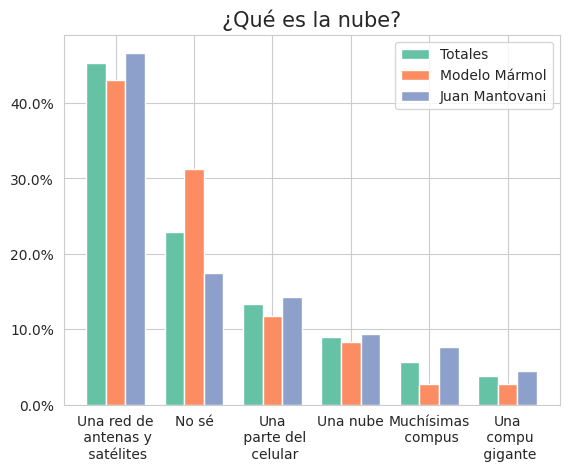

In [12]:
# En informática, ¿qué es la nube?
data_total = df_fe["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol = marmol["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani = mantovani["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"},
                       index={"Una red de antenas y satélites": "Una red de\n antenas y\n satélites",
                              "No sé": "No sé",
                              "Una parte del celular": "Una\n parte del\n celular",
                              "Muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas\n compus",
                              "Una computadora gigante":"Una\n compu\n gigante"}).fillna(0)

bar_width = 0.25

br1 = np.arange(len(data_total))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales'],        width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Mármol'],  width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("¿Qué es la nube?", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()
plt.savefig('que_es_nube.png')

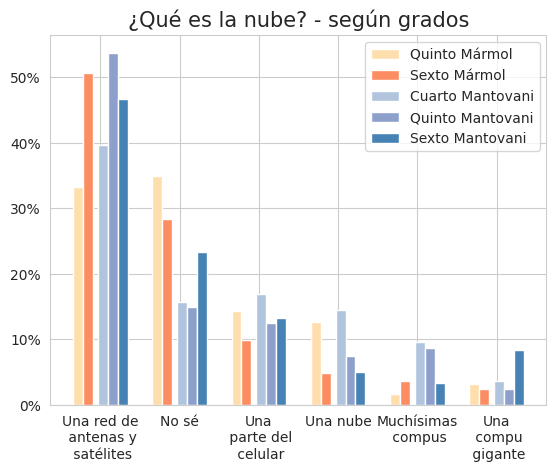

In [16]:
# En informática, ¿qué es la nube? - Grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(     columns={0:'Quinto Mármol',
                                1:'Sexto Mármol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'},
                            index={"Una red de antenas y satélites": "Una red de\n antenas y\n satélites",
                              "No sé": "No sé",
                              "Una parte del celular": "Una\n parte del\n celular",
                              "Muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas\n compus",
                              "Una computadora gigante":"Una\n compu\n gigante"}).fillna(0)

result = result.reindex(["Una red de\n antenas y\n satélites",
                         "No sé",
                         "Una\n parte del\n celular",
                         "Una nube",
                         "Muchísimas\n compus",
                         "Una\n compu\n gigante"
                         ])

br1 = [1, 3, 5, 7, 9, 11]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Mármol']    , width=bar_width, label = 'Quinto Mármol', color='navajowhite')
plt.bar(br2, result['Sexto Mármol']     , width=bar_width, label = 'Sexto Mármol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'] , width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'] , width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani']  , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("¿Qué es la nube? - según grados", fontsize=15)
plt.xticks([x + 2.25*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('que_es_nube_grados.png')

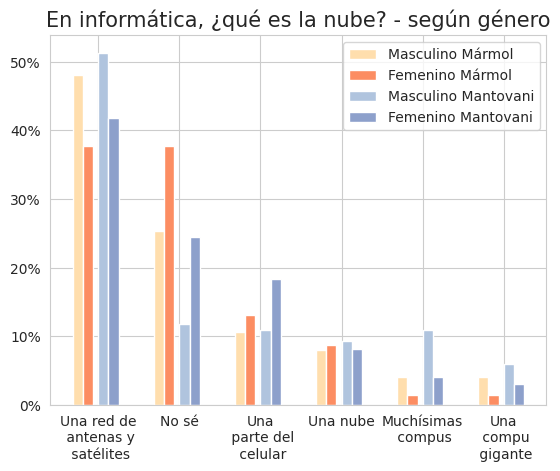

In [28]:
# En informática, ¿qué es la nube? - Género
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Mármol", 1: "Femenino Mármol", 2: "Masculino Mantovani", 3: "Femenino Mantovani"},
                       index={"Una red de antenas y satélites": "Una red de\n antenas y\n satélites",
                              "No sé": "No sé",
                              "Una parte del celular": "Una\n parte del\n celular",
                              "Muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas\n compus",
                              "Una computadora gigante":"Una\n compu\n gigante"}).fillna(0)

result = result.reindex(["Una red de\n antenas y\n satélites",
                         "No sé",
                         "Una\n parte del\n celular",
                         "Una nube",
                         "Muchísimas\n compus",
                         "Una\n compu\n gigante"])

bar_width = 0.25

br1 = [1, 3, 5, 7, 9, 11]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Mármol"],     width=bar_width, label = 'Masculino Mármol', color='navajowhite')
plt.bar(br2,result["Femenino Mármol"],      width=bar_width, label = 'Femenino Mármol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("En informática, ¿qué es la nube? - según género", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('que_es_nube_genero.png')
# Reordenar

# Afirmaciones sobre la nube

In [4]:
# Afirmaciones sobre la nube
afirmaciones_nube

NameError: name 'afirmaciones_nube' is not defined



## conteo de alumnos en esta nueva seccion


## De las siguientes afirmaciones sobre la nube, marcá la o las que creas correctas (podés elegir más de una opción):

## Si cada círculo representa las cosas que podemos hacer con Internet y la nube, ¿cómo creés que se comportan?

# Wikipedia

## ¿Conocés o alguna vez usaste Wikipedia?

## conteo

## Si tengo que hacer un trabajo para la escuela y después de buscar en Wikipedia encuentro un artículo que habla del tema, ¿cuál de las siguientes opciones creés que es la correcta?

---- Hasta la semana que viene? - HAcer  los graficos genericos, despues revisitamos
